<a href="https://colab.research.google.com/github/MaheenZaheer/Machine-Learning/blob/DataPreprocessing/Data_Preprocessing_CO2_emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
!pip install category_encoders

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from category_encoders import MEstimateEncoder
warnings.filterwarnings("ignore")

EDA

In [61]:
df = pd.read_csv("/content/CO2_emission.csv")

In [62]:
df.head()

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935 entries, 0 to 934
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Model_Year                              935 non-null    int64  
 1   Make                                    935 non-null    object 
 2   Model                                   935 non-null    object 
 3   Vehicle_Class                           935 non-null    object 
 4   Engine_Size                             935 non-null    float64
 5   Cylinders                               935 non-null    int64  
 6   Transmission                            935 non-null    object 
 7   Fuel_Consumption_in_City(L/100 km)      935 non-null    float64
 8   Fuel_Consumption_in_City_Hwy(L/100 km)  935 non-null    float64
 9   Fuel_Consumption_comb(L/100km)          935 non-null    float64
 10  CO2_Emissions                           935 non-null    int64 

In [64]:
df.shape

(935, 12)

In [65]:
df.columns

Index(['Model_Year', 'Make', 'Model', 'Vehicle_Class', 'Engine_Size',
       'Cylinders', 'Transmission', 'Fuel_Consumption_in_City(L/100 km)',
       'Fuel_Consumption_in_City_Hwy(L/100 km)',
       'Fuel_Consumption_comb(L/100km)', 'CO2_Emissions', 'Smog_Level'],
      dtype='object')

In [66]:
df.isnull().sum()

,0
Model_Year,0
Make,0
Model,0
Vehicle_Class,0
Engine_Size,0
Cylinders,0
Transmission,0
Fuel_Consumption_in_City(L/100 km),0
Fuel_Consumption_in_City_Hwy(L/100 km),0
Fuel_Consumption_comb(L/100km),0


In [67]:
df.select_dtypes("int64","float64").columns

Index(['Model_Year', 'Cylinders', 'CO2_Emissions', 'Smog_Level'], dtype='object')

In [68]:
numeric = ["Model_Year", "Cylinders", "CO2_Emissions", "Smog_Level"]
numeric

['Model_Year', 'Cylinders', 'CO2_Emissions', 'Smog_Level']

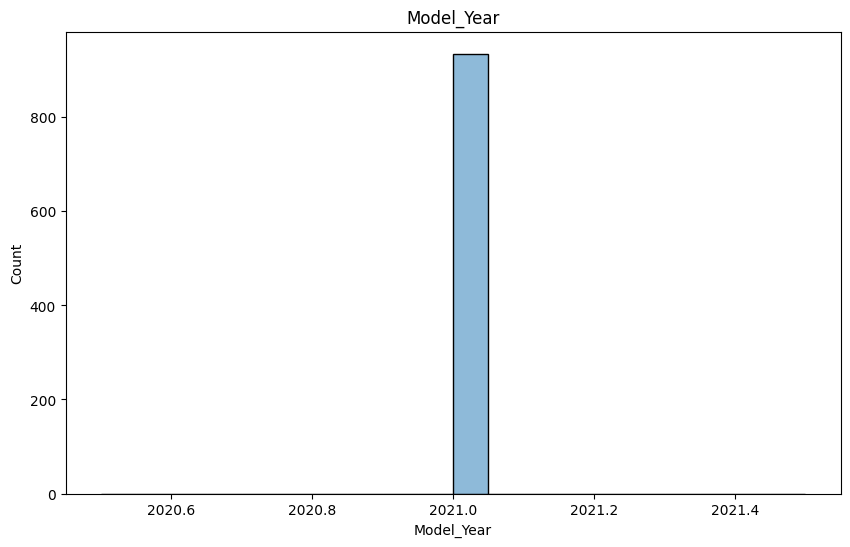

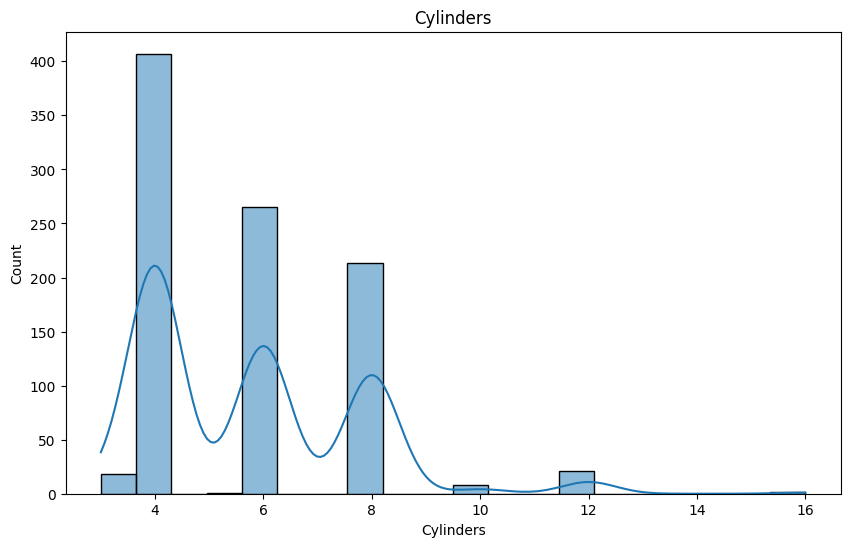

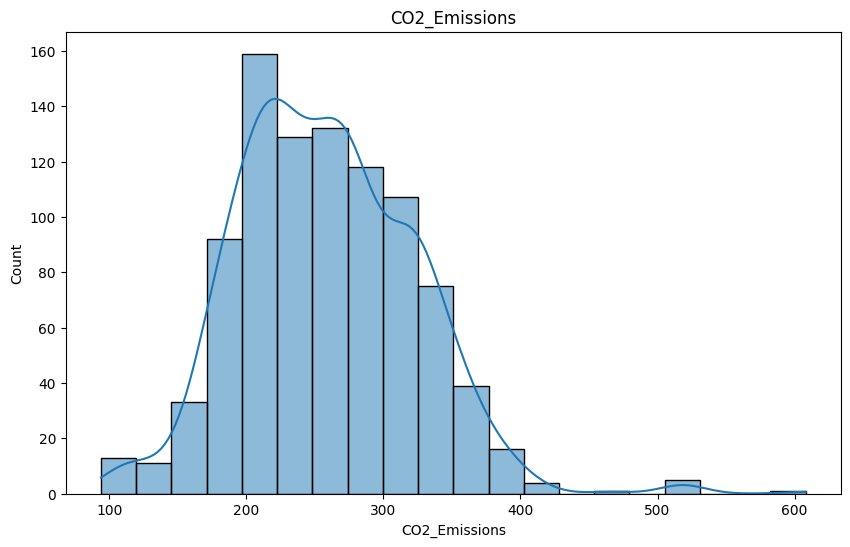

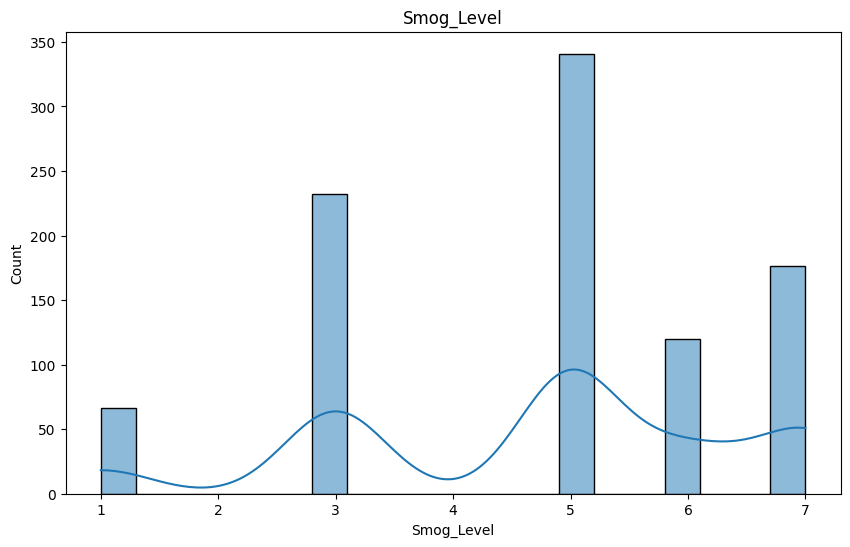

In [69]:
for col in numeric:
    plt.figure(figsize=(10,6))
    plt.title(col)
    sns.histplot(df[col],kde = True,bins=20)
    plt.show()

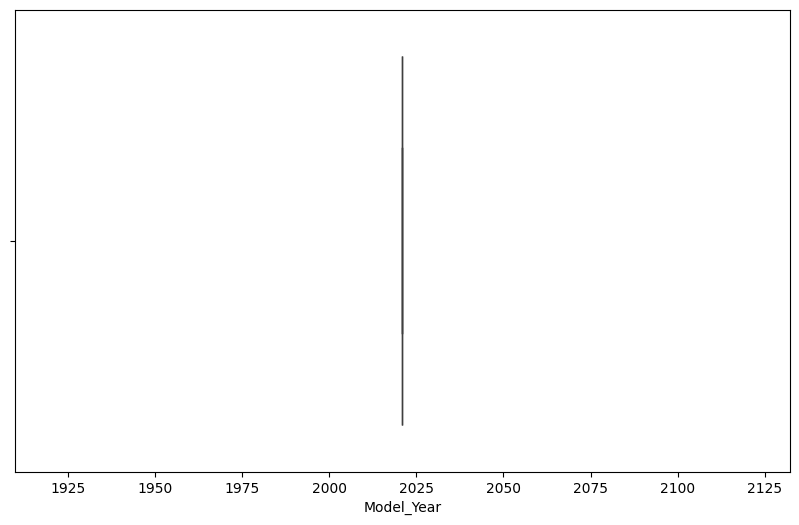

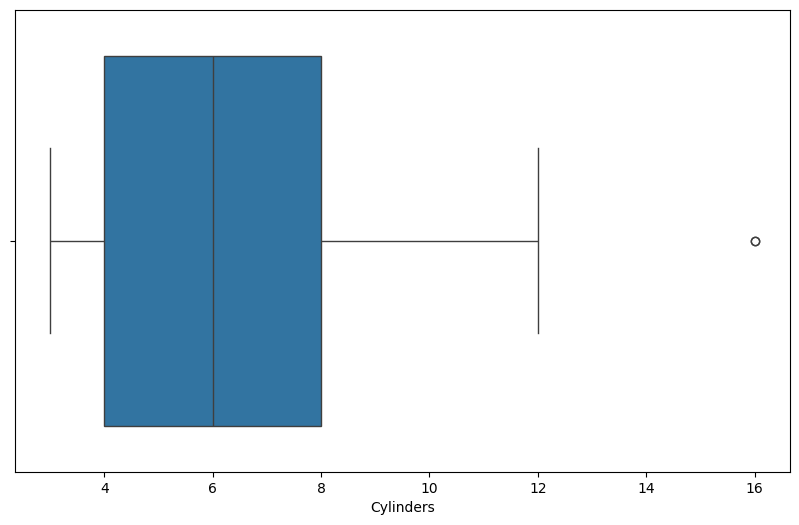

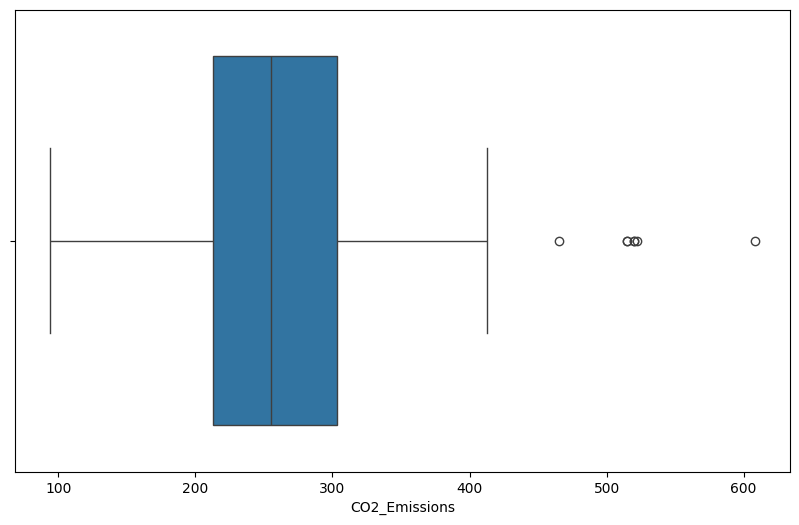

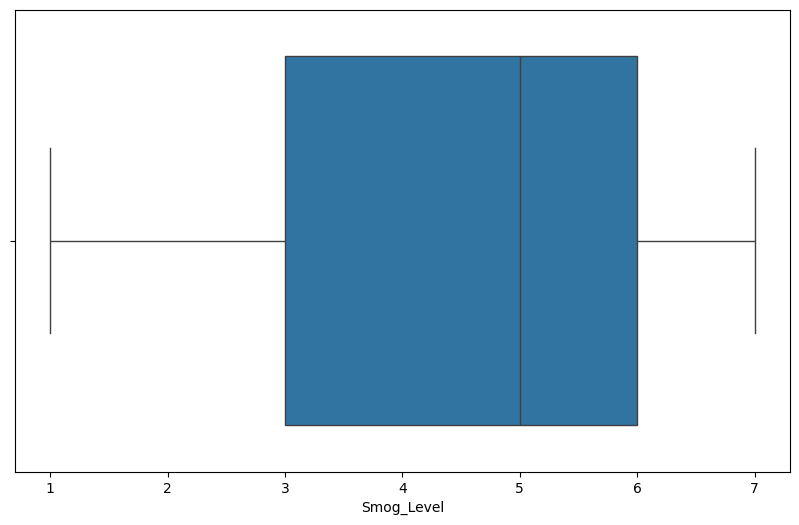

In [70]:
for col in numeric:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=df[col])
  plt.show()

<Axes: >

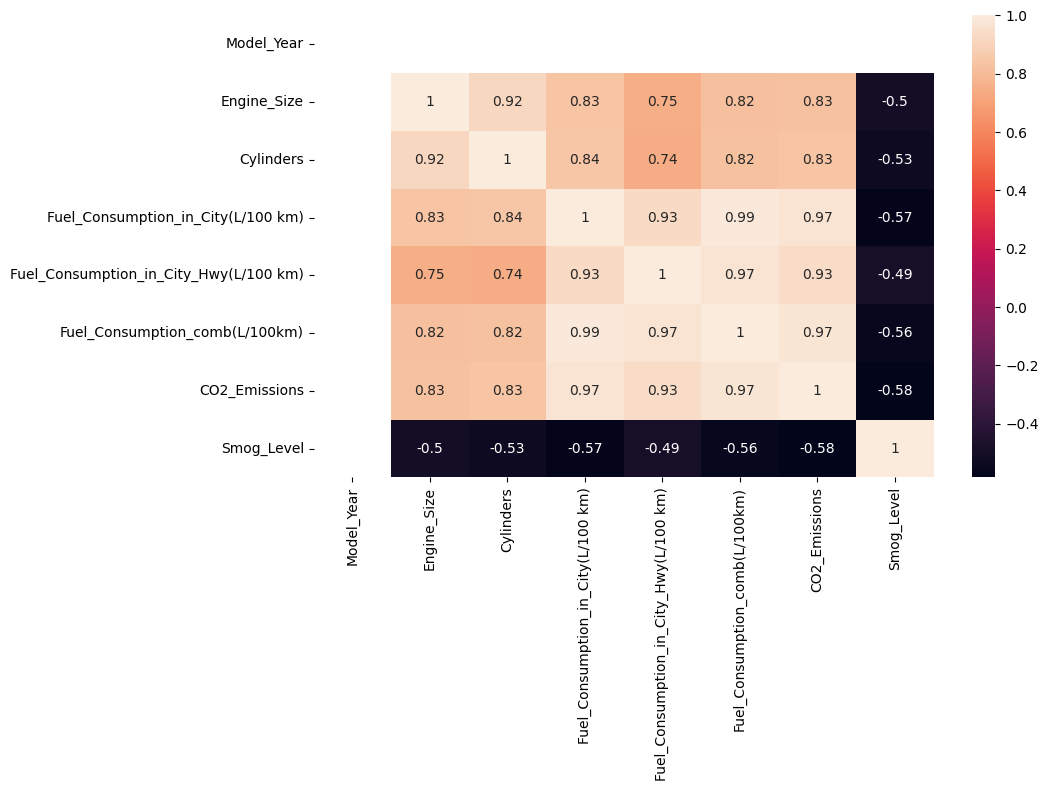

In [71]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Cleaning and Preprocessing

In [72]:
df_clean = df.copy()
df_clean.head()

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7


In [73]:
df_clean.isnull().sum()

,0
Model_Year,0
Make,0
Model,0
Vehicle_Class,0
Engine_Size,0
Cylinders,0
Transmission,0
Fuel_Consumption_in_City(L/100 km),0
Fuel_Consumption_in_City_Hwy(L/100 km),0
Fuel_Consumption_comb(L/100km),0


In [74]:
df_clean.shape

(935, 12)

In [75]:
df_clean.drop_duplicates(inplace=True)

In [76]:
df_clean.shape

(935, 12)

In [77]:
df_clean.dtypes

,0
Model_Year,int64
Make,object
Model,object
Vehicle_Class,object
Engine_Size,float64
Cylinders,int64
Transmission,object
Fuel_Consumption_in_City(L/100 km),float64
Fuel_Consumption_in_City_Hwy(L/100 km),float64
Fuel_Consumption_comb(L/100km),float64


In [78]:
df_clean.Make.value_counts()

,count
Make,
Ford,87
Chevrolet,84
Mercedes-Benz,72
Porsche,63
GMC,61
BMW,54
Toyota,49
Audi,43
Jeep,36


In [79]:
encoder = MEstimateEncoder(cols=['Make'], m=1.0)
df_clean["Make"] = encoder.fit_transform(df_clean["Make"], df_clean["CO2_Emissions"])

In [80]:
df_clean.head()

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,235.504202,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,235.504202,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,235.504202,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,235.504202,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,235.504202,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7


In [81]:
df_clean.Model.value_counts()

,count
Model,
Sierra 4WD,7
Silverado 4WD,7
Sierra,5
Sierra 4WD AT4,5
Mustang,5
...,...
Giulia Quadrifoglio,1
Giulia AWD,1
Giulia,1


In [82]:
encoder1 = MEstimateEncoder(cols=["Model"], m=1.0)
df_clean["Model"] = encoder1.fit_transform(df_clean["Model"], df_clean["CO2_Emissions"])

In [83]:
df_clean.Transmission.value_counts()

,count
Transmission,
AS8,206
A9,95
A8,92
AS10,77
AM7,70
M6,67
A10,59
AS6,56
AM8,44


In [84]:
encoder2 = MEstimateEncoder(cols=["Transmission"], m=1.0)
df_clean["Transmission"] = encoder2.fit_transform(df_clean["Transmission"], df_clean["CO2_Emissions"])

In [85]:
df_clean.Vehicle_Class.value_counts()

,count
Vehicle_Class,
SUV: Small,192
SUV: Standard,127
Pickup truck: Standard,115
Mid-size,114
Compact,83
Subcompact,83
Full-size,65
Two-seater,56
Minicompact,30


In [86]:
encoder3 = MEstimateEncoder(cols = ["Vehicle_Class"], m=1.0)
df_clean["Vehicle_Class"] = encoder3.fit_transform(df_clean["Vehicle_Class"], df_clean["CO2_Emissions"])

In [87]:
df_clean


,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,235.504202,228.764706,212.494398,2.4,4,279.833987,9.9,7.0,8.6,199,3
1,2021,235.504202,257.264706,303.746130,3.5,6,257.264706,11.1,10.8,11.0,256,3
2,2021,235.504202,245.264706,231.738494,2.0,4,277.352941,11.0,8.6,9.9,232,6
3,2021,235.504202,250.264706,231.738494,2.0,4,277.352941,11.3,9.1,10.3,242,6
4,2021,235.504202,244.264706,212.494398,2.0,4,277.352941,11.2,8.0,9.8,230,7
...,...,...,...,...,...,...,...,...,...,...,...,...
930,2021,224.823529,238.764706,231.738494,2.0,4,262.253765,10.7,7.7,9.4,219,5
931,2021,224.823529,244.264706,231.738494,2.0,4,262.253765,11.1,8.3,9.9,230,5
932,2021,224.823529,249.264706,231.738494,2.0,4,262.253765,11.7,8.6,10.3,240,7
933,2021,224.823529,247.264706,303.519761,2.0,4,262.253765,11.5,8.4,10.1,236,5


feature engineering and scalling

<Axes: >

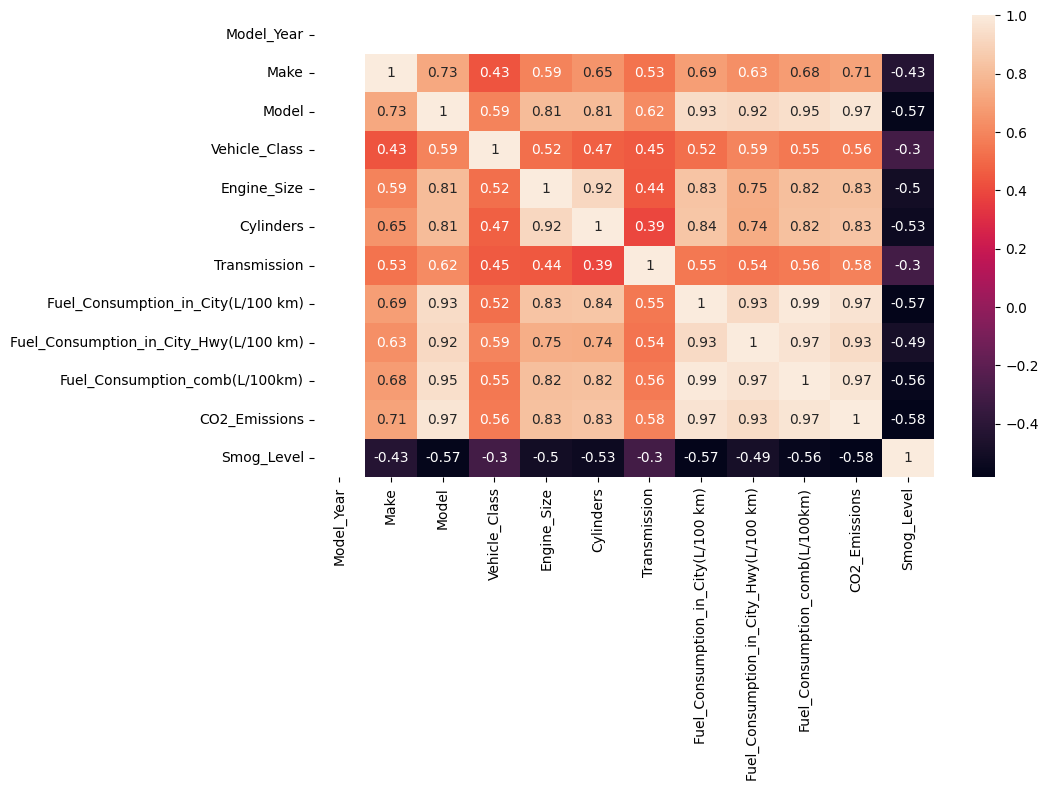

In [90]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)


In [95]:
df_clean.drop(["Fuel_Consumption_in_City(L/100 km)", "Fuel_Consumption_in_City_Hwy(L/100 km)"], axis=1,inplace = True)

KeyError: "['Fuel_Consumption_in_City(L/100 km)', 'Fuel_Consumption_in_City_Hwy(L/100 km)'] not found in axis"

In [96]:
df_clean

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,235.504202,228.764706,212.494398,2.4,4,279.833987,8.6,199,3
1,2021,235.504202,257.264706,303.746130,3.5,6,257.264706,11.0,256,3
2,2021,235.504202,245.264706,231.738494,2.0,4,277.352941,9.9,232,6
3,2021,235.504202,250.264706,231.738494,2.0,4,277.352941,10.3,242,6
4,2021,235.504202,244.264706,212.494398,2.0,4,277.352941,9.8,230,7
...,...,...,...,...,...,...,...,...,...,...
930,2021,224.823529,238.764706,231.738494,2.0,4,262.253765,9.4,219,5
931,2021,224.823529,244.264706,231.738494,2.0,4,262.253765,9.9,230,5
932,2021,224.823529,249.264706,231.738494,2.0,4,262.253765,10.3,240,7
933,2021,224.823529,247.264706,303.519761,2.0,4,262.253765,10.1,236,5


In [101]:
df_clean.drop(["Model_Year"],axis = 1, inplace = True)

<Axes: >

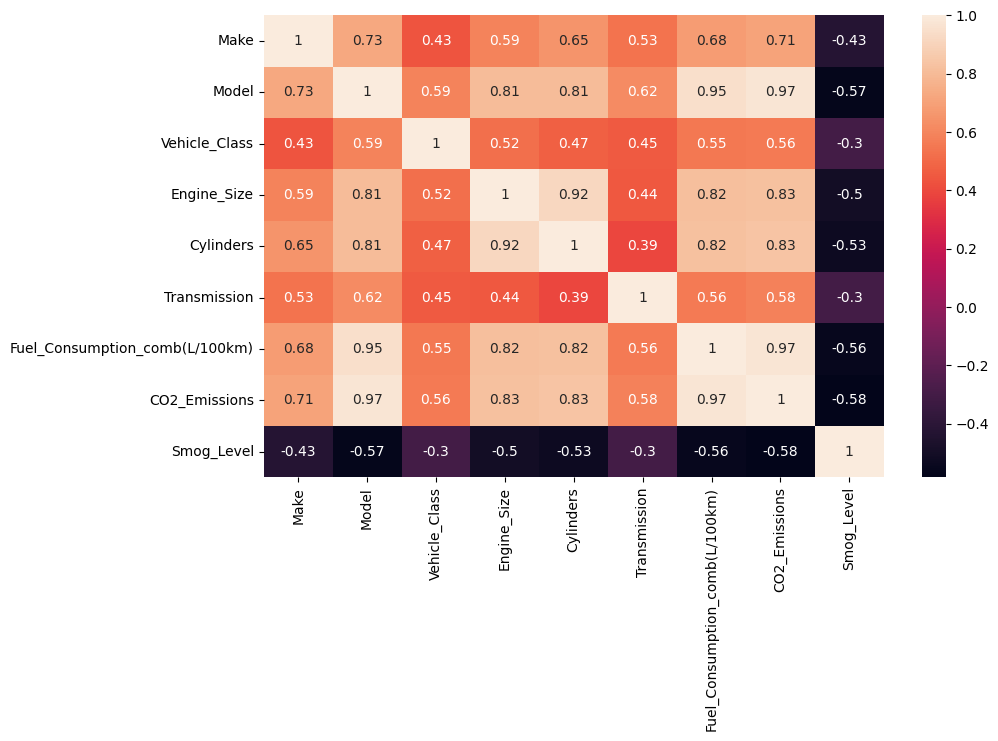

In [102]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

In [105]:
from sklearn.preprocessing import StandardScaler as scaler

In [106]:
standard = df_clean.copy()
scaler = scaler()

In [110]:
array = scaler.fit_transform(standard.drop(columns=["CO2_Emissions"],axis=1))
df_scaled = pd.DataFrame(array,columns=standard.drop(["CO2_Emissions"],axis=1).columns)

In [111]:
df_scaled

,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_comb(L/100km),Smog_Level
0,-0.54256,-0.833136,-1.296970,-0.587177,-0.868581,0.585024,-0.858565,-1.008761
1,-0.54256,-0.039337,1.276392,0.205462,0.143411,-0.047168,-0.021013,-1.008761
2,-0.54256,-0.373568,-0.754273,-0.875409,-0.868581,0.515527,-0.404891,0.744383
3,-0.54256,-0.234305,-0.754273,-0.875409,-0.868581,0.515527,-0.265299,0.744383
4,-0.54256,-0.401421,-1.296970,-0.875409,-0.868581,0.515527,-0.439789,1.328765
...,...,...,...,...,...,...,...,...
930,-0.79617,-0.554610,-0.754273,-0.875409,-0.868581,0.092582,-0.579381,0.160002
931,-0.79617,-0.401421,-0.754273,-0.875409,-0.868581,0.092582,-0.404891,0.160002
932,-0.79617,-0.262158,-0.754273,-0.875409,-0.868581,0.092582,-0.265299,1.328765
933,-0.79617,-0.317863,1.270008,-0.875409,-0.868581,0.092582,-0.335095,0.160002
